# Life & Health Insurance Claims Analysis

## Business Objective

The objective of this project is to analyze insurance claims data to identify customer segments, claim patterns, and business insights that can help insurance companies better understand risk and support data-driven decision making.

## Dataset Overview

This dataset contains synthetic life and health insurance claims data.

Each record represents an individual customer and includes demographic information, socioeconomic characteristics, and the associated insurance claim amount.

### Features

- **Age** – Customer age
- **Gender** – Customer gender
- **Income** – Annual income
- **Marital_Status** – Marital status
- **Education** – Education level
- **Occupation** – Occupation
- **Claim_Amount** – Insurance claim amount

## Data Loading

The dataset is downloaded directly from Kaggle using `kagglehub` to keep the project reproducible.

In [76]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ravalsmit/insurance-claims-and-policy-data")

print("Path to dataset files:", path)

Path to dataset files: /Users/yonatan/.cache/kagglehub/datasets/ravalsmit/insurance-claims-and-policy-data/versions/2


In [77]:
from pathlib import Path

dataset_path = Path(path)

for file in sorted(dataset_path.iterdir()):
    print(file.name)

data_synthetic.csv
insurance_dataset.csv


In [78]:
import pandas as pd

df = pd.read_csv(dataset_path / "insurance_dataset.csv")

df.head()


,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount
0,59.0,Male,270727.0,Single,Master's,Doctor,3455.0
1,21.0,Female,263874.0,Single,Bachelor's,Engineer,30233.0
2,71.0,Female,48372.0,Single,Bachelor's,Engineer,340.0
3,30.0,Female,99525.0,Single,PhD,CEO,1002.0
4,64.0,Female,187038.0,Married,Master's,CEO,2828.0


## Initial Data Exploration

Before performing any analysis, it is important to understand the structure and quality of the dataset.

This section examines the dataset dimensions, data types, summary statistics, missing values, duplicate records, and categorical features.

In [79]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             13000 non-null  float64
 1   Gender          13000 non-null  str    
 2   Income          13000 non-null  float64
 3   Marital_Status  13000 non-null  str    
 4   Education       13000 non-null  str    
 5   Occupation      13000 non-null  str    
 6   Claim_Amount    13000 non-null  float64
dtypes: float64(3), str(4)
memory usage: 711.1 KB


In [80]:
df.describe()


,Age,Income,Claim_Amount
count,13000.000000,13000.000000,13000.000000
mean,51.530308,161718.427413,9185.646615
std,20.965770,99965.550464,15041.942150
min,18.000000,5091.000000,114.000000
25%,34.000000,75080.750000,3344.750000
50%,51.000000,154855.500000,5829.500000
75%,67.000000,235395.250000,8293.250000
max,102.421544,404427.908255,99841.000000


In [91]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Age               0
Gender            0
Income            0
Marital_Status    0
Education         0
Occupation        0
Claim_Amount      0
dtype: int64

Duplicate rows:
0


In [92]:
for column in ["Gender", "Marital_Status", "Education", "Occupation"]:
    print(f"\n{column}")
    print(df[column].value_counts())


Gender
Gender
Female    6541
Male      6459
Name: count, dtype: int64

Marital_Status
Marital_Status
Single     6513
Married    6487
Name: count, dtype: int64

Education
Education
Master's      4383
PhD           4321
Bachelor's    4296
Name: count, dtype: int64

Occupation
Occupation
CEO         10575
Engineer      633
Doctor        624
Waiter        587
Teacher       581
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us better understand the distribution of the data, identify unusual values, and explore potential relationships between variables before answering business questions.

### Distribution of Numerical Features

We begin by examining the distribution of the numerical variables to understand their spread, identify skewness, and detect potential outliers.

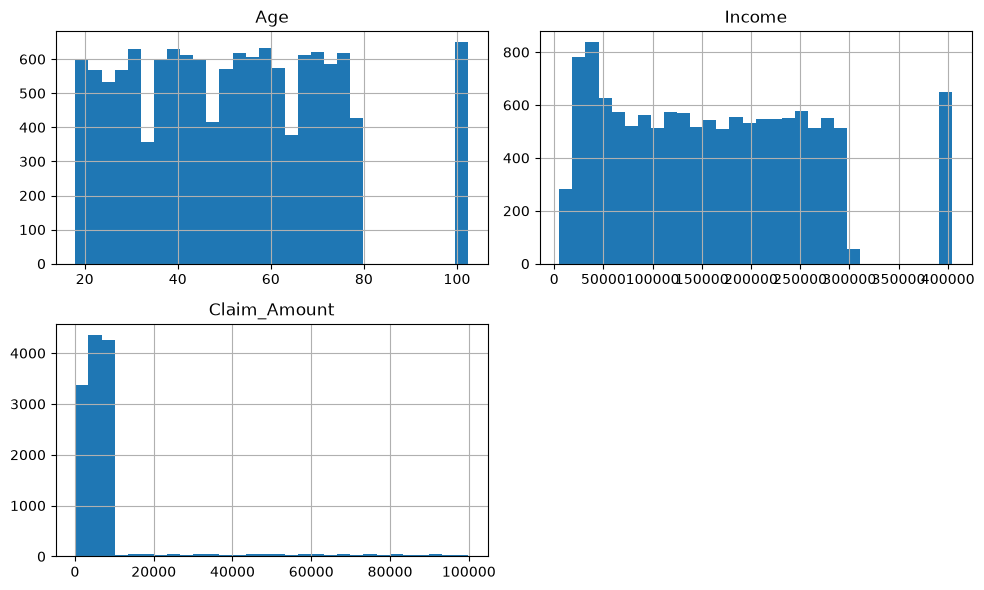

In [93]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 6), bins=30)

plt.tight_layout()
plt.show()

### Outlier Detection

Boxplots provide a quick way to identify extreme values and compare the distribution of each numerical feature.

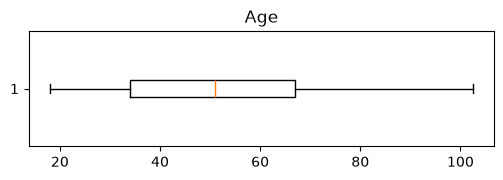

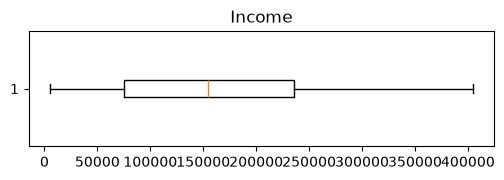

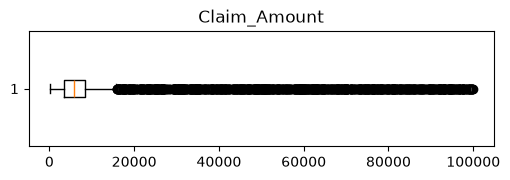

In [94]:
numeric_columns = ["Age", "Income", "Claim_Amount"]

for column in numeric_columns:
    plt.figure(figsize=(6, 1.5))
    plt.boxplot(df[column], orientation="horizontal")
    plt.title(column)
    plt.show()

### Correlation Analysis

Correlation analysis measures the strength of the linear relationship between numerical variables.

In [95]:
corr = df[["Age", "Income", "Claim_Amount"]].corr(numeric_only=True)

corr

,Age,Income,Claim_Amount
Age,1.00000,-0.001650,0.006490
Income,-0.00165,1.000000,0.024806
Claim_Amount,0.00649,0.024806,1.000000


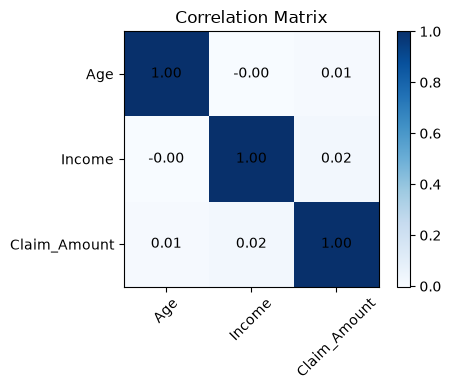

In [96]:
plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="Blues", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Business Questions

The following analyses are designed to answer business-oriented questions that could help an insurance company better understand customer behavior, identify high-risk segments, and support strategic decision making.

## Business Question 1

### Which customer groups generate the highest insurance claim amounts?

Understanding which customer segments tend to submit higher insurance claims can help insurers improve risk assessment, pricing strategies, and customer segmentation.

In [97]:
avg_claim_by_occupation = (
    df.groupby("Occupation")["Claim_Amount"]
      .mean()
      .sort_values(ascending=False)
)

avg_claim_by_occupation

Occupation
Waiter      22761.655877
Doctor      22040.639423
Engineer    21685.851501
Teacher     20251.779690
CEO          6317.307518
Name: Claim_Amount, dtype: float64

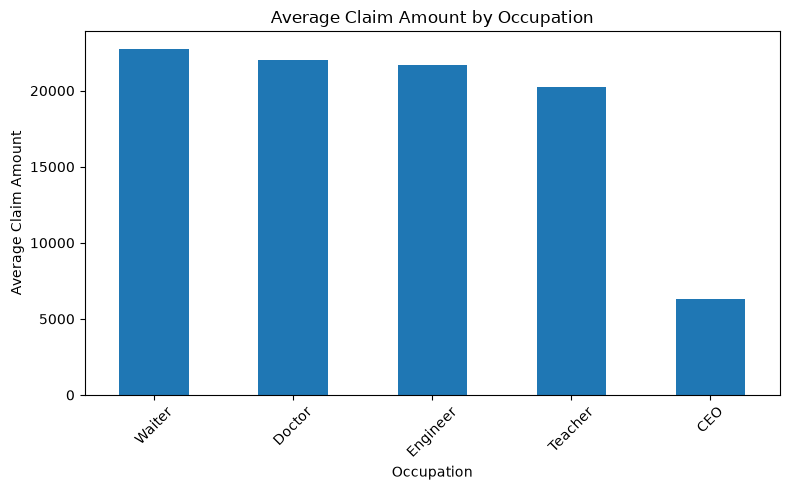

In [98]:
plt.figure(figsize=(8,5))

avg_claim_by_occupation.plot(kind="bar")

plt.title("Average Claim Amount by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Claim Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight

Occupation appears to be an important segmentation variable, but the group sizes are highly unbalanced.

Most records belong to the CEO category, while the remaining occupations contain far fewer observations. Therefore, average claim values should be interpreted together with the number of customers in each group.

In [99]:
occupation_summary = (
    df.groupby("Occupation")
      .agg(
          Customer_Count=("Claim_Amount", "size"),
          Average_Claim=("Claim_Amount", "mean"),
          Median_Claim=("Claim_Amount", "median"),
          Total_Claims=("Claim_Amount", "sum")
      )
      .sort_values("Average_Claim", ascending=False)
)

occupation_summary.round(2)

,Customer_Count,Average_Claim,Median_Claim,Total_Claims
Occupation,,,,
Waiter,587,22761.66,7879.0,13361092.0
Doctor,624,22040.64,7730.5,13753359.0
Engineer,633,21685.85,7997.0,13727144.0
Teacher,581,20251.78,7214.0,11766284.0
CEO,10575,6317.31,5592.0,66805527.0


The median claim amount is included because the claim distribution is strongly right-skewed.

Unlike the mean, the median is less affected by unusually large claims and provides a more representative view of a typical customer within each occupation.

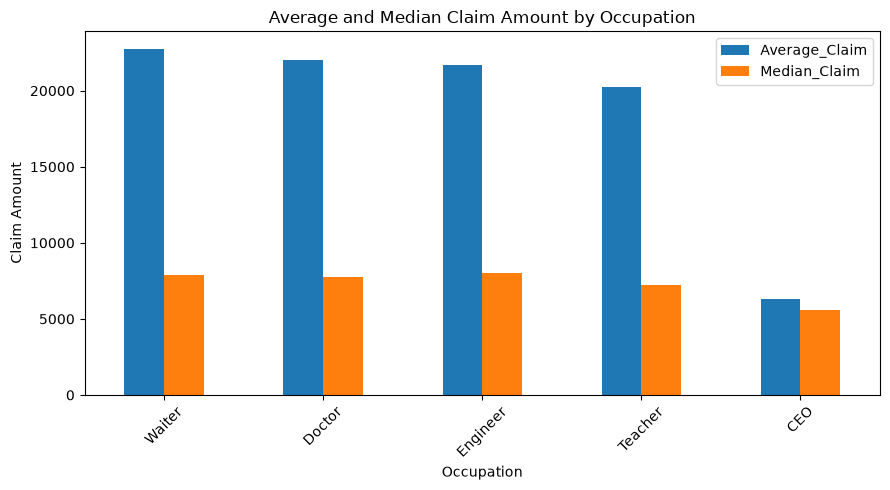

In [100]:
occupation_claims = (
    occupation_summary[["Average_Claim", "Median_Claim"]]
    .sort_values("Average_Claim", ascending=False)
)

occupation_claims.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average and Median Claim Amount by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Claim Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Question 2

### How does customer age relate to insurance claim amounts?

Analyzing claims across age groups can help identify whether certain life stages are associated with higher insurance costs.

In [101]:
age_bins = [18, 30, 40, 50, 60, 70, float("inf")]
age_labels = ["18–29", "30–39", "40–49", "50–59", "60–69", "70+"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,59.0,50–59
1,21.0,18–29
2,71.0,70+
3,30.0,30–39
4,64.0,60–69


In [102]:
age_group_summary = (
    df.groupby("Age_Group", observed=False)
      .agg(
          Customer_Count=("Claim_Amount", "size"),
          Average_Claim=("Claim_Amount", "mean"),
          Median_Claim=("Claim_Amount", "median")
      )
)

age_group_summary.round(2)

,Customer_Count,Average_Claim,Median_Claim
Age_Group,,,
18–29,2266,8760.59,5707.0
30–39,2033,9319.43,5782.0
40–49,1979,9095.51,5902.0
50–59,2064,9545.04,5849.0
60–69,1967,9348.14,5937.0
70+,2691,9114.36,5791.0


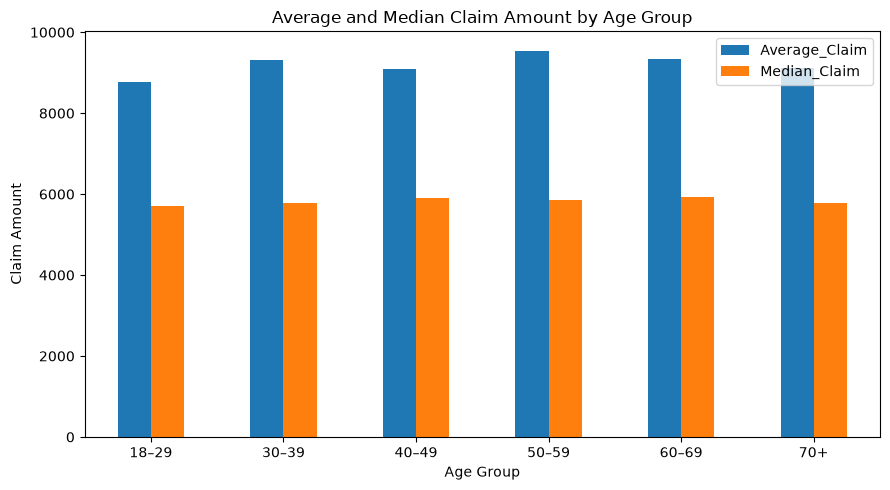

In [103]:
age_group_summary[["Average_Claim", "Median_Claim"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average and Median Claim Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Claim Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Business Insight

The analysis shows no meaningful relationship between customer age and insurance claim amounts.

Average and median claim amounts remain relatively stable across all age groups, suggesting that age alone is not a strong predictor of claim value in this dataset.

This indicates that other customer characteristics may have a greater influence on insurance claims.

## Business Question 3

### Does annual income influence insurance claim amounts?

Income is often considered an important factor in customer profiling. This analysis examines whether customers with higher annual income tend to generate larger insurance claims.

In [105]:
income_bins = [0, 50000, 100000, 150000, 200000, 250000, float("inf")]

income_labels = [
    "<50K",
    "50K-100K",
    "100K-150K",
    "150K-200K",
    "200K-250K",
    "250K+"
]

df["Income_Group"] = pd.cut(
    df["Income"],
    bins=income_bins,
    labels=income_labels,
    right=False
)

In [106]:
income_summary = (
    df.groupby("Income_Group", observed=False)
      .agg(
          Customer_Count=("Claim_Amount", "size"),
          Average_Claim=("Claim_Amount", "mean"),
          Median_Claim=("Claim_Amount", "median")
      )
)

income_summary.round(2)

,Customer_Count,Average_Claim,Median_Claim
Income_Group,,,
<50K,2200,7770.91,5577.5
50K-100K,2043,9150.99,5762.0
100K-150K,2058,9656.75,5911.0
150K-200K,1991,9649.37,5869.0
200K-250K,2070,9598.17,5933.0
250K+,2638,9351.11,5889.5


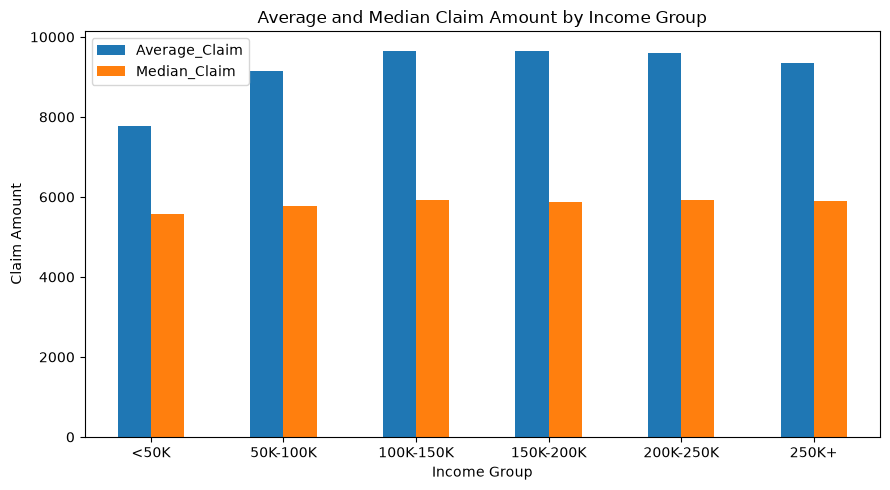

In [107]:
income_summary[
    ["Average_Claim", "Median_Claim"]
].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average and Median Claim Amount by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Claim Amount")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Business Insight

The analysis indicates that annual income has only a limited impact on insurance claim amounts.

Average and median claims remain relatively consistent across all income groups, suggesting that income alone is not a strong indicator of claim value within this dataset.

## Business Question 4

### Do insurance claim amounts differ by gender and education level?

Understanding differences between demographic groups can help insurers identify meaningful customer segments and improve pricing and risk assessment strategies.

In [108]:
gender_education_summary = (
    df.groupby(
        ["Gender", "Education"]
    )["Claim_Amount"]
    .mean()
    .unstack()
)

gender_education_summary.round(2)

Education,Bachelor's,Master's,PhD
Gender,,,
Female,9222.21,9731.32,8741.77
Male,9115.03,8976.35,9305.41


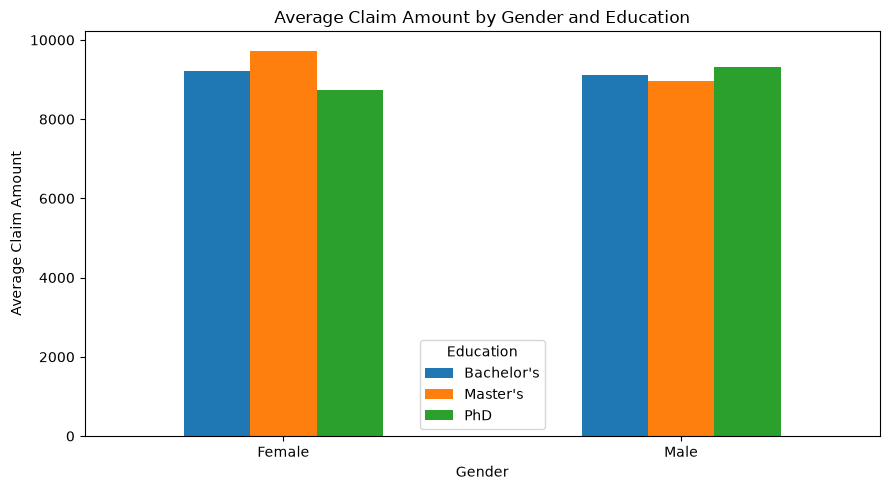

In [109]:
gender_education_summary.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Claim Amount by Gender and Education")
plt.xlabel("Gender")
plt.ylabel("Average Claim Amount")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Business Insight

Only minor differences can be observed between gender and education groups.

The results suggest that neither gender nor education level has a substantial influence on insurance claim amounts in this dataset. More advanced analysis using additional variables may be required to identify stronger predictors of insurance claims.

# Executive Summary

This project analyzed a synthetic life and health insurance claims dataset to better understand customer characteristics and insurance claim behavior.

The analysis included data exploration, quality assessment, descriptive statistics, and business-oriented analyses focusing on occupation, age, income, gender, and education.

The results show that most demographic variables have only a limited impact on claim amounts. Although some differences exist between customer groups, no single variable appears to be a strong predictor of insurance claims on its own.

These findings demonstrate the importance of combining multiple customer attributes when performing insurance risk analysis and customer segmentation.

# Key Findings

- The dataset contains clean, high-quality data with no missing values or duplicate records.
- Claim amounts are highly right-skewed, with a relatively small number of very large claims.
- Occupation shows some variation in average claim amounts, although customer group sizes differ considerably.
- Customer age does not demonstrate a meaningful relationship with insurance claim amounts.
- Annual income has only a limited influence on claim values.
- Gender and education level show only minor differences in average insurance claims.
- No strong linear correlation was found between the numerical variables in the dataset.

# Business Recommendations

Based on the analysis performed in this project, the following recommendations can be considered:

### 1. Improve Customer Segmentation
Since individual demographic variables show only a limited impact on claim amounts, insurers should combine multiple customer characteristics when building customer segments.

### 2. Develop Multi-Factor Risk Models
Age, income, gender, and education alone are not strong predictors of insurance claims. Future predictive models should incorporate additional variables such as medical history, policy type, lifestyle factors, and previous claim history.

### 3. Monitor High-Value Claims
The claim amount distribution is highly right-skewed, indicating that a relatively small number of claims account for a significant portion of total claim costs. These cases should receive additional monitoring and investigation.

### 4. Improve Data Collection
Additional business variables such as policy coverage, premium amount, claim type, and policy duration would enable deeper analysis and support more accurate risk assessment.

### 5. Support Data-Driven Decision Making
This analysis demonstrates how exploratory data analysis and business intelligence techniques can help insurance companies better understand customer behavior and support evidence-based decision making.

# Conclusion

This project demonstrated a complete business analytics workflow, starting from data acquisition and exploration through exploratory data analysis, business-oriented questions, and actionable recommendations.

Although the dataset is synthetic, the analytical approach reflects a real-world business analytics process that can be applied to insurance and other customer-focused industries.